<a href="https://colab.research.google.com/github/AnushaFreshStart/DL-agriculture-A/blob/main/Q3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Question 3

Task 1: Create a transformation pipeline `custom_transform` for:  

    1. image size = 64 × 64 pixels

    2. RandomHorizontalFlip probability 0.5

    3. RandomVerticalFlip probability 0.2

    4. RandomRotation of 45 degrees

In [ ]:
from torchvision import transforms

custom_transform = transforms.Compose([
    transforms.Resize((64, 64)),  # 1. Resize to 64x64 pixels
    transforms.RandomHorizontalFlip(p=0.5),  # 2. Horizontal flip with prob 0.5
    transforms.RandomVerticalFlip(p=0.2),  # 3. Vertical flip with prob 0.2
    transforms.RandomRotation(degrees=45),  # 4. Random rotation of 45 degrees
    transforms.ToTensor(),  # Convert PIL image to Tensor
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]
    ),  # Normalize to [-1, 1]
])

In [ ]:
from torchvision import datasets

# Load dataset and apply custom transformations
imagefolder_dataset = datasets.ImageFolder(
    root=base_dir, transform=custom_transform
)

In [ ]:
# Print class names and their corresponding numerical indices
print("Class names:", imagefolder_dataset.classes)
print("Class-to-index mapping:", imagefolder_dataset.class_to_idx)

Class names: ['class_0_non_agri', 'class_1_agri']
Class-to-index mapping: {'class_0_non_agri': 0, 'class_1_agri': 1}


In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 8

# Create DataLoader for ImageFolder dataset
imagefolder_loader = DataLoader(
    imagefolder_dataset, batch_size=BATCH_SIZE, shuffle=True
)

# Fetch a single batch of images and labels
images_inbuilt, labels_inbuilt = next(iter(imagefolder_loader))

# Display the batch dimensions [Batch, Channels, Height, Width]
print(f"Images batch shape (ImageFolder loader): {images_inbuilt.shape}")
print(f"Labels batch shape (ImageFolder loader): {labels_inbuilt.shape}")

Images batch shape (ImageFolder loader): torch.Size([8, 3, 64, 64])
Labels batch shape (ImageFolder loader): torch.Size([8])


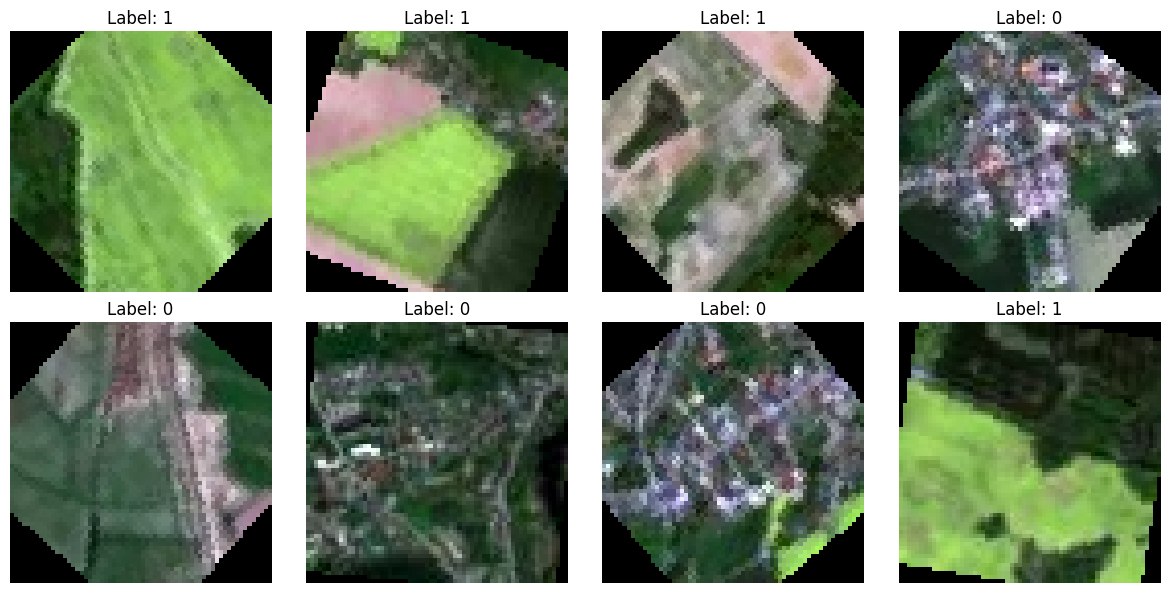

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def imshow(img):
  """Helper function to un-normalize and display an image tensor."""
  img = img / 2 + 0.5  # Un-normalize from [-1, 1] to [0, 1]
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0)))  # Convert (C, H, W) to (H, W, C)


# Display images from the inbuilt loader batch (corrected variables)
plt.figure(figsize=(12, 6))
for i in range(len(images_inbuilt)):
  ax = plt.subplot(2, 4, i + 1)
  imshow(images_inbuilt[i])
  plt.title(f"Label: {labels_inbuilt[i].item()}")
  plt.axis("off")

plt.tight_layout()
plt.show()